# Structural Vulnerability Analysis on MDOF System using Cloud Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing a nonlinear time-history analyses (NLTHA), namely cloud analysis on multi-degree-of-freedom (MDOF) structural models using natural unscaled ground-motion records. By combining functions for MDOF calibration, modeling and dynamic analysis, the notebook enables the setup, execution, and post-processing of structural responses under earthquake loading.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights, fundamental period and nonlinear response characteristics at each degree of freedom

3. **Run Nonlinear Time-History Analysis (NLTHA) in OpenSees**: Simulate the dynamic response of MDOF structures under time-dependent inputs, such as ground motion records, to realistically assess structural behavior and response metrics (e.g., peak storey drifts, peak floor accelerations) under loading conditions and extract critical response metrics and model information.

4. **Fragility Analysis**: Postprocess cloud analysis results to fit a probabilistic seismic demand model (PSDM) to ultimately estimate the median seismic intensities and total dispersion associated with arbitrary demand-based thresholds (i.e., maximum interstorey drift-based) and construct the fragility functions relating damage state exceedance probabilities with increasing levels of ground-shaking.

5. **Vulnerability Analysis**: Integrate fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable and increasing levels of ground-shaking.


The notebook provides a step-by-step guide, covering each phase from MDOF model calibration, setup to input parameter configuration, analysis execution, and detailed results extraction and postprocessing. Users should have some familiarity with python scripts, structural dynamics, computational modeling, and performance-based earthquake engineering to fully benefit from this material.

---

## References

[1] Jalayer, F., De Risi, R. & Manfredi, G. Bayesian Cloud Analysis: efficient structural fragility assessment using linear regression. Bull Earthquake Eng 13, 1183–1203 (2015). https://doi.org/10.1007/s10518-014-9692-z

[2] Jalayer F, Ebrahimian H, Miano A, Manfredi G, Sezen H. Analytical fragility assessment using unscaled ground motion records. Earthquake Engng Struct Dyn. 2017; 46: 2639–2663. https://doi.org/10.1002/eqe.2922

[3] Miano A, Jalayer F, Ebrahimian H, Prota A. Cloud to IDA: Efficient fragility assessment with limited scaling. Earthquake Engng Struct Dyn. 2018; 47: 1124–1147. https://doi.org/10.1002/eqe.3009

[4] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi:10.1177/8755293019891724

[5] Silva, V. (2019) Uncertainty and correlation in seismic vulnerability functions of building classes. Earthquake Spectra DOI: 10.1193/013018eqs031m.

## Initialize Libraries ##

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openquake.vmtk.units import units
from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.modeller import modeller
from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.plotter import plotter
from openquake.vmtk.utilities import sorted_alphanumeric, import_from_pkl, export_to_pkl

## Define Directories ##

In [2]:
# Define the directory of the ground-motion records
gm_directory  = './in/records'            

# Define the main output directory
nrha_directory = './out/analysis'  
os.makedirs(nrha_directory, exist_ok=True)

## Load ESRM20 Pre-Processed Intensity Measures ##

The records used in this demonstration are derived from the datasets utilized in the development of the European Seismic Risk Model (2020). These records were previously post-processed in a separate demonstration file titled “IntensityMeasureProcessing.” 

The records are available on: https://gitlab.seismo.ethz.ch/efehr/esrm20_vulnerability/-/tree/master/scripts/vmtk/gmrs?ref_type=heads

If you use these records, please cite as follows:

X. Romão, N. Pereira, J.M. Castro, H. Crowley, V. Silva, L. Martins, & F. De Maio. (2021). European Building Vulnerability Data Repository. Zenodo. https://doi.org/10.5281/zenodo.4062410

In [3]:
# Import the intensity measure dictionary (output from "IntensityMeasureProcessing" demo)
ims  = import_from_pkl(os.path.join(gm_directory, 'imls_esrm20.pkl'))  

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [ ]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [[0.00060789, 0.00486316, 0.02420000, 0.04353684],  # spectral displacement [m]
     [0.10315200, 0.20630401, 0.12378241, 0.12502023]]  # spectral acceleration [g]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = True

# Inherent damping
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

## Setting Up, Running and Exporting Cloud Analysis ##

In the next code snippet, a cloud-based nonlinear time-history analysis is performed on the pre-calibrated stick model using a suite of recorded ground-motion time histories from the European Seismic Risk Model 2020 (Crowley et al.).

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent cloud regression, fragility development, and vulnerability analysis.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


============== Analysing: 1 out of 200 ==================


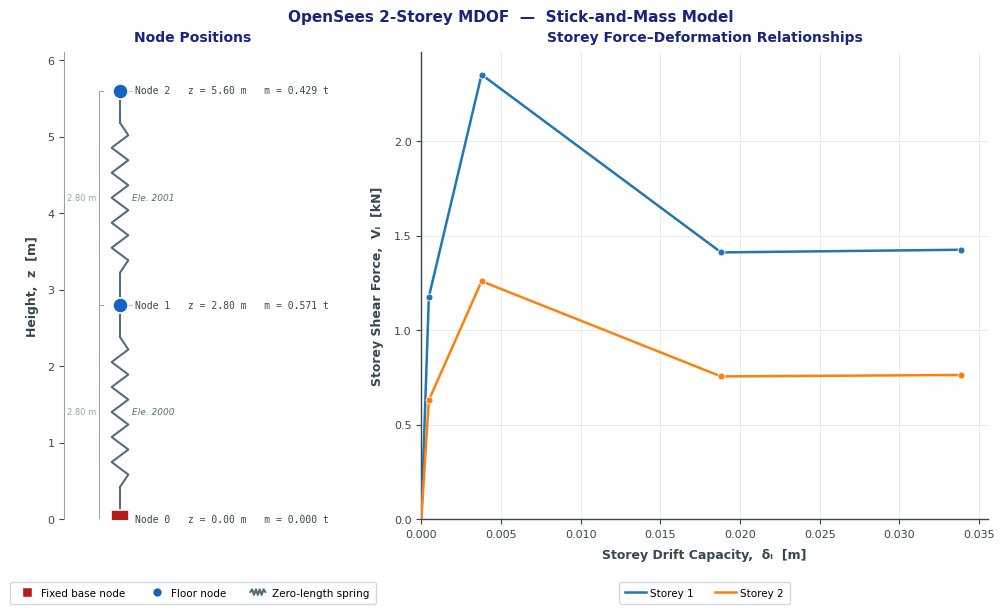

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 2 out of 200 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 3 out of 200 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 4 out of 200 ==================


...

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 199 out of 200 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 200 out of 200 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
ANALYSIS COMPLETED!


In [5]:
# Initialise MDOF storage lists
conv_index_list = []               # List for convergence indices
peak_disp_list  = []               # List for peak floor displacement (returns all peak values along the building height)
peak_drift_list = []               # List for peak storey drift (returns all peak values along the building height)
peak_accel_list = []               # List for peak floor acceleration (returns all peak values along the building height)
max_peak_drift_list = []           # List for maximum peak storey drift (returns the maximum value) 
max_peak_drift_dir_list = []       # List for maximum peak storey drift directions
max_peak_drift_loc_list = []       # List for maximum peak storey drift locations
max_peak_accel_list = []           # List for maximum peak floor acceleration (returns the maximum value)
max_peak_accel_dir_list = []       # List for maximum peak floor acceleration directions 
max_peak_accel_loc_list = []       # List for maximum peak floor acceleration locations
total_hyst_energy_list = []        # List for total hysteretic energy dissipated
storey_hyst_energy_list = []       # List for storey-based hysteretic energy dissipated

# Loop over ground-motion records, compile MDOF model and run NLTHA
# The set of ground-motion records utilized correspond to the acceleration time-histories of the European Seismic Risk Model 2020 (Crowley et al.)
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory,'acc')))                         # Sort the ground-motion records alphanumerically
dts  = sorted_alphanumeric(os.listdir(os.path.join(gm_directory,'dts')))                         # Sort the ground-motion time-step files alphanumerically

# Run the analysis
for i in range(len(gmrs)):
    ### Print post-processing iteration
    print('================================================================')
    print('============== Analysing: {:d} out of {:d} =================='.format(i+1, len(gmrs)))
    print('================================================================')

    ### Compile the MDOF model    
    model = modeller(number_storeys,
                     storey_heights,
                     floor_masses,
                     storey_drifts,
                     storey_forces*units.g,
                     mdof_degradation)                                                                # Initialise the class (Build the model)
    
    model.compile_model()                                                                             # Compile the MDOF model
    
    if i==0:
        model.plot_model()                                                                            # Visualise the model (only on first iteration)        
    model.do_gravity_analysis()                                                                       # Do gravity analysis

    if number_storeys == 1:
        num_modes = 1
    else:
        num_modes = 3
    T, phi = model.do_modal_analysis(num_modes = num_modes, plot_modes = False)                       # Do modal analysis and get period of vibration (Essential step for running NLTHA)
    
    ### Define ground motion objects
    fnames = [os.path.join(gm_directory,'acc',f'{gmrs[i]}')]                                          # Ground-motion record names
    fdts   =  os.path.join(gm_directory,'dts',f'{dts[i]}')                                            # Ground-motion time-step names 
    dt_gm = pd.read_csv(fdts, header=None)[pd.read_csv(fdts,header=None).columns[0]].loc[1]-\
            pd.read_csv(fdts, header=None)[pd.read_csv(fdts,header=None).columns[0]].loc[0]           # Ground-motion time-step
    t_max = pd.read_csv(fdts)[pd.read_csv(fdts).columns[0]].iloc[-1]                                  # Ground-motion duration
    
    ### Define analysis params and do NLTHA
    dt_ansys = dt_gm                                                            # Set the analysis time-step
    sf = units.g                                                                # Set the scaling factor (if records are in g, a scaling factor of 9.81 m/s2 must be used to be consistent with opensees) 
    control_nodes, conv_index, peak_drift, peak_accel, max_peak_drift, max_peak_drift_dir, max_peak_drift_loc, max_peak_accel, max_peak_accel_dir, max_peak_accel_loc, peak_disp, storey_hyst_energy, total_hyst_energy = model.do_nrha_analysis(fnames, 
                                                                                                                                                                                                                                                 dt_gm, 
                                                                                                                                                                                                                                                 sf, 
                                                                                                                                                                                                                                                 t_max, 
                                                                                                                                                                                                                                                 dt_ansys,
                                                                                                                                                                                                                                                 pFlag=False,
                                                                                                                                                                                                                                                 xi = mdof_damping)

    ### Store the analysis
    conv_index_list.append(conv_index)
    peak_drift_list.append(peak_drift)
    peak_accel_list.append(peak_accel)
    peak_disp_list.append(peak_disp)
    max_peak_drift_list.append(max_peak_drift)
    max_peak_drift_dir_list.append(max_peak_drift_dir)
    max_peak_drift_loc_list.append(max_peak_drift_loc)
    max_peak_accel_list.append(max_peak_accel)
    max_peak_accel_dir_list.append(max_peak_accel_dir)
    max_peak_accel_loc_list.append(max_peak_accel_loc)
    storey_hyst_energy_list.append(storey_hyst_energy)
    total_hyst_energy_list.append(total_hyst_energy)

# Store the analysis results in a dictionary
ansys_dict = {}
labels = ['T','control_nodes', 'conv_index_list',
          'peak_drift_list','peak_accel_list',
          'max_peak_drift_list', 'max_peak_drift_dir_list', 
          'max_peak_drift_loc_list','max_peak_accel_list',
          'max_peak_accel_dir_list','max_peak_accel_loc_list',
          'peak_disp_list', 'total_hyst_energy_list', 'storey_hyst_energy_list']

for i, label in enumerate(labels):
    ansys_dict[label] = vars()[f'{label}']

# Export the analysis output variable to a pickle file using the "export_to_pkl" function from "utilities"
export_to_pkl(os.path.join(nrha_directory,'cloud_out.pkl'), ansys_dict) 

# Print statement
print('ANALYSIS COMPLETED!')

## Post-Process Cloud Analysis Results: Probabilistic Seismic Demand Model and Fragility Functions ##

### The Probabilistic Seismic Demand Model: IM-EDP Relationship

#### Step 1: Classical Cloud Analysis 

**Cloud Analysis (CA)** [1,2,3] is a method used in structural engineering to assess the fragility of structures under seismic events. It involves performing nonlinear dynamic analyses using **a set of "natural" recorded ground motions without scaling them**, and then applying simple linear regression in the logarithmic space of structural response using engineering demand parameters (EDP) versus seismic intensity measure levels (IM). This approach allows for efficient estimation of structural fragility by considering the inherent variability in ground motions. Following the methodology proposed in [1,2,3], the **Modified Cloud Analysis (MCA)** approach, provides a systematic framework for estimating seismic fragility functions using CA, while explicitly **accounting for structural collapse cases through Logistic regression and probabilistic combination**.

The EDP–IM relationship is first expressed as:

$$
EDP = a \, IM^{\,b}
$$

Applying a logarithmic transformation yields a linear regression model:

$$
\ln(EDP) = \ln(a) + b \ln(IM)
$$

where:

- $\ln(a)$ and $b$ are the regression intercept and slope, estimated via least-squares fitting,  

The record-to-record uncertainty, expressed as the logarithmic standard deviation of the EDP conditioned on the IM, is given by:

$$
\beta_{EDP \,|\, IM}
\approx
\sqrt{
\frac{
\sum_{i=1}^{n}
\left[
\ln(EDP_i) - \ln(a \, IM_i^{\,b})
\right]^2
}
{n - 2}
}
$$

where $n$ is the number of non-collapse ground-motion records.


#### Step 2: Modified Cloud Analysis and Treatment of Collapse Cases

In nonlinear dynamic analyses, numerical non-convergence or excessive response may indicate structural collapse, commonly defined by exceeding a collapse threshold $EDP \ge EDP_C$. Such cases cannot be directly included in classical cloud regression due to undefined or unbounded EDP values.

Using the Total Probability Theorem, the probability of exceeding a damage state $DS$ at a given intensity level is decomposed into two mutually exclusive events: collapse (C) and no-collapse (NC):

$$
P(DS \,|\, IM)
=
P(DS \,|\, NC, IM)\,P(NC \,|\, IM)
+
P(DS \,|\, C, IM)\,P(C \,|\, IM)
$$

Since exceeding any damage state is guaranteed given collapse:

$$
P(DS \,|\, C, IM) = 1
$$

the expression simplifies to:

$$
P(DS \,|\, IM)
=
P(DS \,|\, NC, IM)\,[1 - P(C \,|\, IM)]
+
P(C \,|\, IM)
$$

where:

- $P(DS \,|\, NC, IM)$ is the fragility derived from cloud regression using only non-collapse data,  
- $P(C \,|\, IM)$ is the probability of collapse.


Subsequently, the probability of collapse is estimated using Logistic regression as a function of the intensity measure:

$$
P(C \,|\, IM)
=
\frac{1}
{1 + \exp\!\left[-\left(\alpha_0 + \alpha_1 \ln(IM)\right)\right]}
$$

where $\alpha_0$ and $\alpha_1$ are regression coefficients fitted to collapse / non-collapse outcomes.


#### Note on Statistical Stabilisation via Bootstrapping

Modified Cloud Analysis is often based on a limited number of ground-motion records, which can lead to numerical instability and sensitivity to outliers. 
**Bootstrapping** is employed to improve robustness. The procedure to pre-process MCA data using bootstrapping is outlined as such:

1. **Resampling**: Generate $N$ bootstrap datasets (e.g., $N = 200$) by random sampling with replacement from the original dataset.

2. **Estimation**: For each bootstrap sample, perform cloud regression on non-collapse records and Logistic regression for collapse probability.

3. **Aggregation**: Compute the mean probability of exceedance across all bootstrap realizations.

The main benefits of using bootstrapping as a pre-processing step are reducing the influence of individual extreme ground motions,  produces a smoother transition in the fragility curve as intensity approaches collapse-dominated areas, enables estimation of epistemic uncertainty through percentile bounds (e.g., 16th and 84th percentiles). This combined framework yields statistically stable and physically consistent fragility functions that explicitly account for both demand variability and collapse phenomena within the Modified Cloud Analysis methodology.


### Fragility Function Derivation

Fragility functions describe the probability that a structure will reach or exceed a given damage state as a function of an intensity measure (IM). In this framework, fragility functions are assumed to follow a lognormal distribution, which is commonly adopted in seismic risk assessment due to its ability to capture uncertainty in structural response.

Let $P(DS \ge ds_i ,|, IM)$ denote the probability that damage state $ds_i$ is exceeded at a given intensity measure level $IM$. Under the lognormal assumption, this probability is expressed as

$$
P(DS \ge ds_i ,|, IM) =
\Phi \left(
\frac{\ln(IM) - \ln(\theta_{ds_i})}{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\theta_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation for damage state $ds_i$
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function

The total dispersion $\beta_{ds_i}^{\text{total}}$ accounts for multiple sources of uncertainty and is computed as the root sum of squares of the individual components:

$$
\beta_{ds_i}^{\text{total}} =
\sqrt{
\beta_{\text{record-to-record}}^2 +
\beta_{\text{building-to-building}}^2 +
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ or $\beta_{\text{EDP|IM}}$  represents variability due to ground motion record-to-record uncertainty
* $\beta_{\text{building-to-building}}$ or $\beta_{\text{MDL}}$ captures variability in structural properties across nominally similar buildings
* $\beta_{\text{DS}}$ represents uncertainty associated with the definition and threshold of the damage state

This formulation ensures that the fragility functions consistently incorporate the combined effects of aleatory and epistemic uncertainties across all damage states.

In [6]:
# Intensity measure to use for postprocessing cloud analyses
IMT      = 'PGA'
   
# Import the intensity measure levels associated the PGA
imls = ims[f'{IMT}']                   

# Import the engineering demand parameters (i.e., maximum peak storey drifts) from the analysis dictionary
edps = ansys_dict['max_peak_drift_list']  

# Damage thresholds (Drift-based values in rad)
damage_thresholds    =  [0.00150, 0.00545, 0.00952, 0.0135] 

# The lower limit to be applied for censoring edp values (Recommendation: below 0.1 the minimum threshold for slight damage is considered a negligible case)
lower_limit = 0.1*damage_thresholds[0]

# The upper limit to be applied for consoring edp values (Recommendation: above 1.5 the maximum threshold is considered a collapse case) 
censored_limit = 1.5*damage_thresholds[-1]   

# The modelling uncertainty due to differences in actual response properties (capacity  curves) among nominally similar buildings
sigma_build2build = 0.3

# The uncertainty in damage state threshold since the demand-based damage thresholds are estimated based on limit empirical data and/or expert judgment
sigma_ds = 0.3
 
# Initialise the postprocessor class
pp = postprocessor()

# Process modified cloud analysis results using the "do_modified_cloud_analysis" function called from "postprocessor" 
# The output will be automatically stored in a dictionary
cloud_dict = pp.do_modified_cloud_analysis(imls,                                  # Intensity measure levels 
                                           edps,                                  # Engineering demand parametrs 
                                           damage_thresholds,                     # Demand-based damage thresholds  
                                           lower_limit,                           # Lower censoring limit (below which EDPs are small values and do not contribute to damage)
                                           censored_limit,                        # Upper censoring limit (where usually dynamic instability or collapse is thought to be achieved) 
                                           sigma_build2build = sigma_build2build, # The modelling uncertainty
                                           sigma_ds          = sigma_ds)          # The uncertainty in DS threshold

## Visualise Cloud Analysis Results for Various IM Types: Demands, Probabilistic Seismic Demand Models, Fragility Functions ##

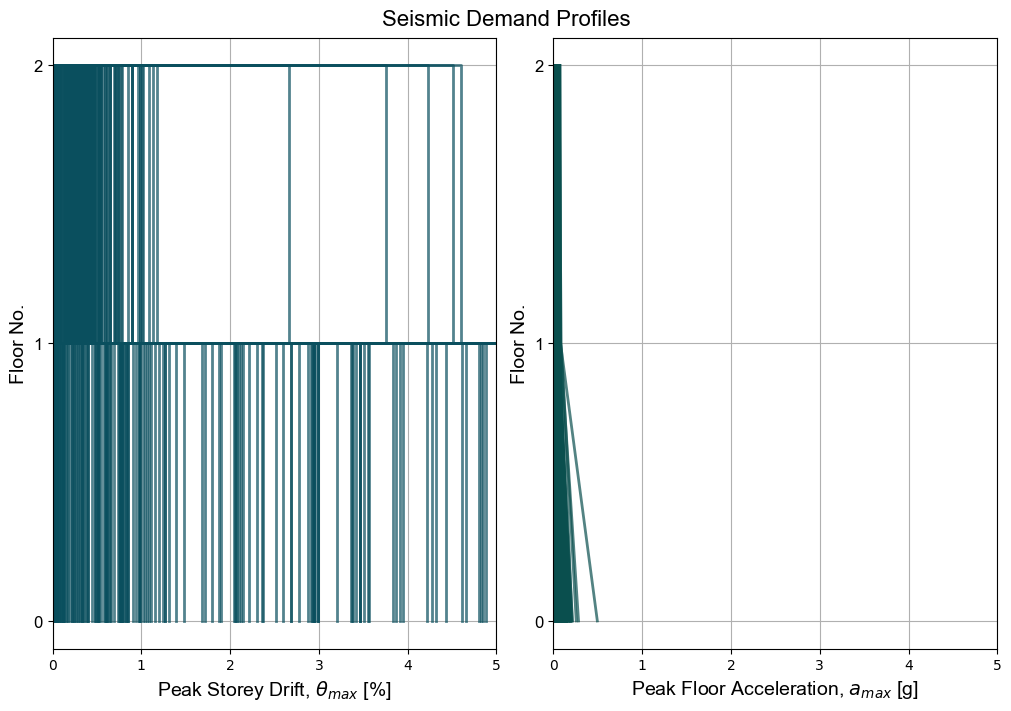

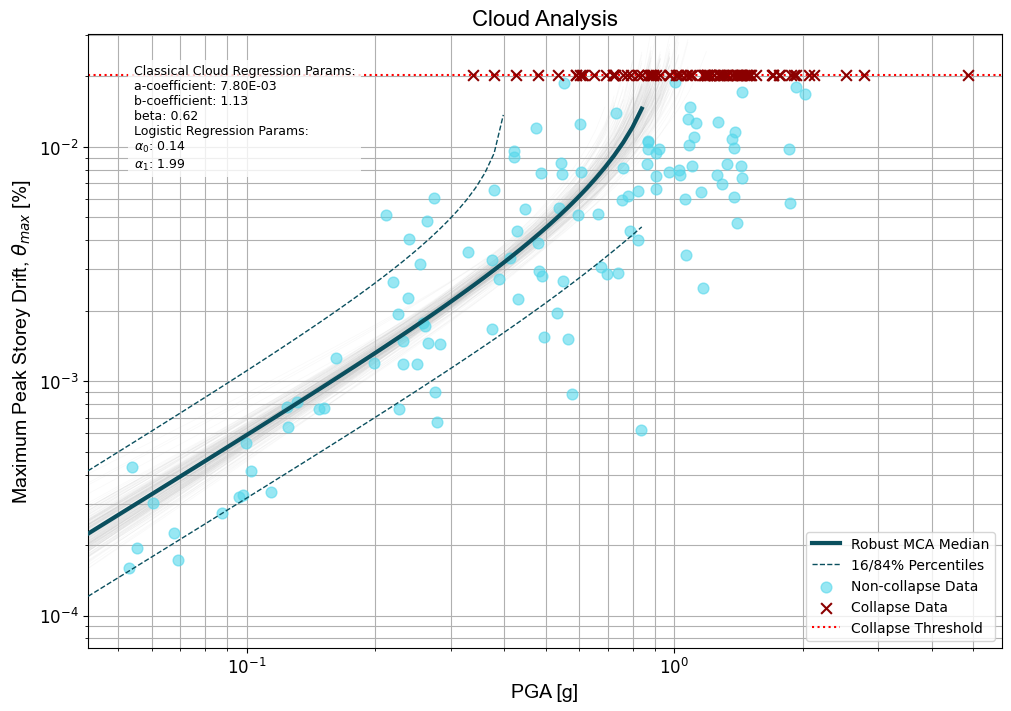

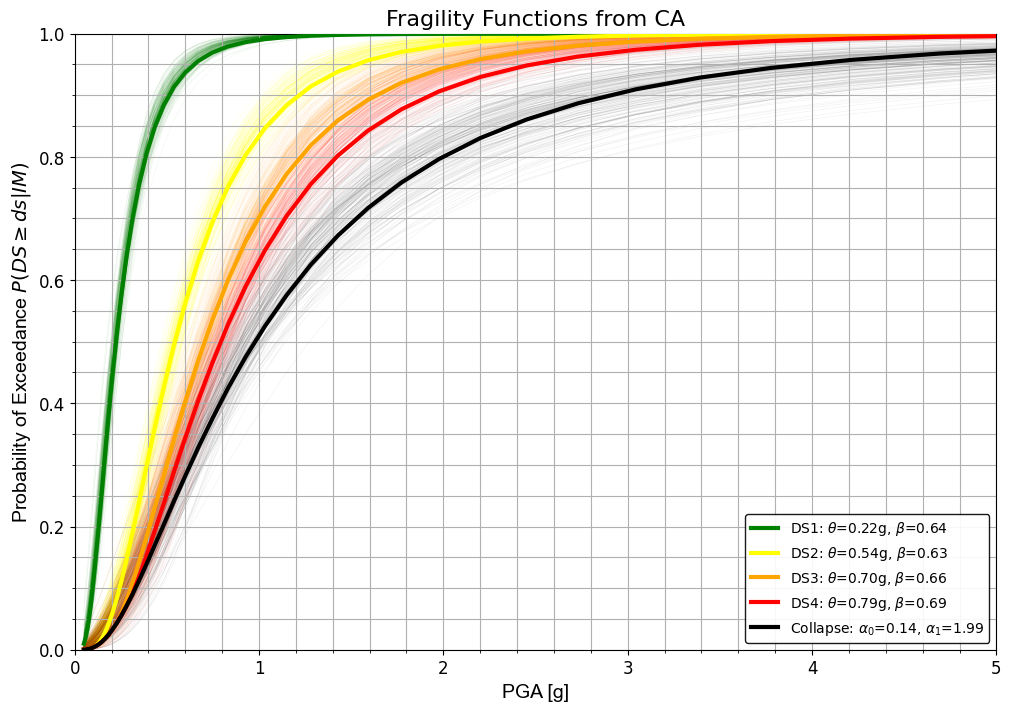

In [7]:
# Initialise the plotter class
pl = plotter()

# Visualise the seismic demands: the y-axis values for drifts and accelerations are converted to % and g automatically by the plotter    
pl.plot_demand_profiles(ansys_dict['peak_drift_list'],                   # Drifts
                        ansys_dict['peak_accel_list'],                   # Accelerations
                        ansys_dict['control_nodes'],                     # Control nodes
                        title = 'Seismic Demand Profiles',               # Plot title  
                        pFlag = True,                                    # Printing flag (if False, plot does not render, but is saved in export_path)
                        export_path = 'out/demand_profiles.png') # Output path (with filename and extension)

# Visualise the cloud analysis results
pl.plot_mca_analysis(cloud_dict,                                           # Cloud analysis dictionary 
                     f'{IMT} [g]',                                         # Intensity measure label
                     r'Maximum Peak Storey Drift, $\theta_{max}$ [%]',     # Engineering demand parameter label
                     title = 'Cloud Analysis',                             # Plot title 
                     pFlag = True,                                         # Printing flag (if False, plot does not render, but is saved in export_path)
                     export_path = 'out/cloud_analysis.png')       # Output path (with filename and extension)

# Visualise the fragility functions
xlims = [0, 5]
ylims = [0, 1]
pl.plot_fragility_from_mca(cloud_dict,                                      # Cloud analysis dictionary
                           f'{IMT} [g]',                                    # Intensity measure label
                           xlims,                                           # X-axis limit
                           ylims,                                           # Y-axis limit 
                           plot_bootstrap = True,                           # Bootstrap plotting flag (if True, plots fragility functions from each bootstrap sample)
                           title = 'Fragility Functions from CA',           # Plot title 
                           pFlag = True,                                    # Printing flag (if False, plot does not render, but is saved in export_path)
                           export_path='out/fragility_curves.png')  # Output path (with filename and extension)

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ (or $\beta_{\text{MDL}}$) captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [5] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [5].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [5], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5
\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
* 2,\overline{LR}_{\mid IM}
- \sqrt{6.8,\overline{LR}_{\mid IM} + 0.5}
  \right)
  }
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}*{LR,i},\mu*{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM),[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM),\kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)],\kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [8]:
# Define consequence model to relate structural damage to a decision variable (i.e., expected loss ratio) 
consequence_model = [0.05, 0.20, 0.60, 1.00] # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00] 

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(cloud_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                            consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                            cov_consequence = consequence_cov,      # The coefficient of variation model representing the uncertainty around the loss ratios per damage state
                                                                            uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                            method='explicit')                      # Set method to explicit for COV calculation per law of total variance         

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(cloud_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                         consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                         uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                         method='silva')                         # Set method to Silva for semi-empirical COV calculation     

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

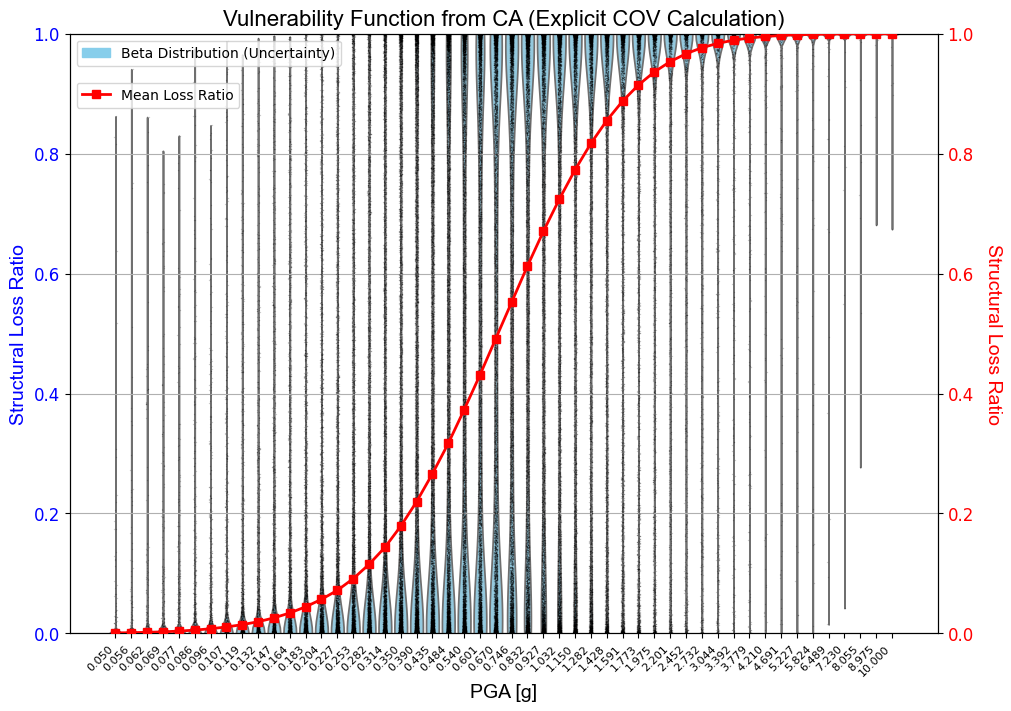

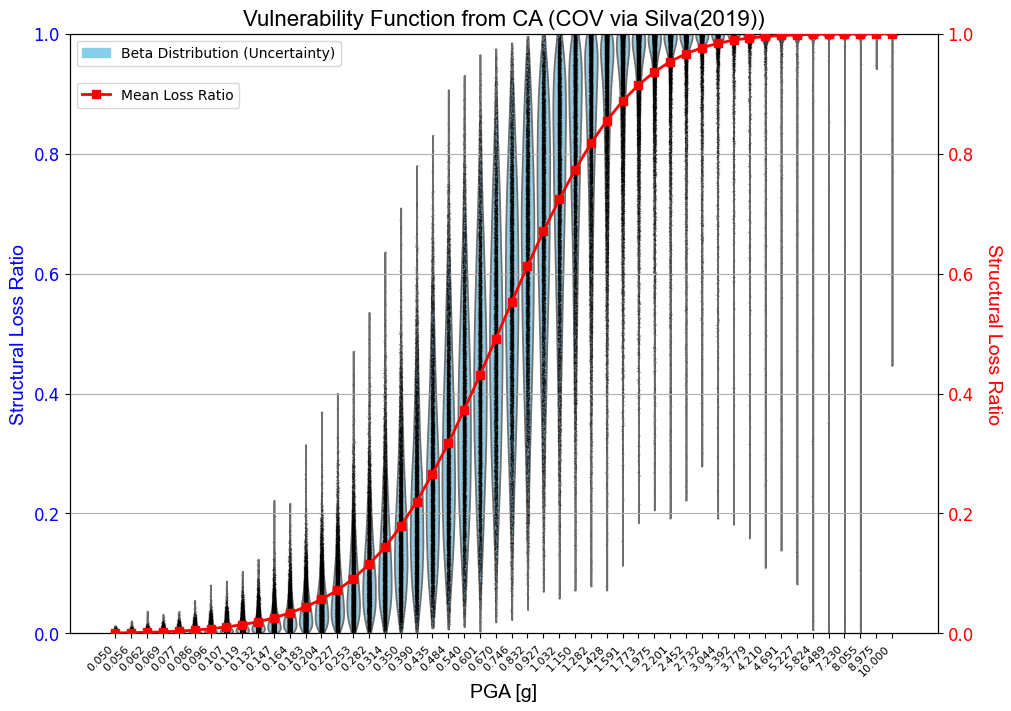

In [9]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label   = f'{IMT} [g]',
                               loss_label      = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (Explicit COV Calculation)',
                               pFlag       = True,
                               export_path = 'out/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label   = f'{IMT} [g]',
                               loss_label      = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (COV via Silva(2019))',
                               pFlag       = True,
                               export_path = 'out/vulnerability_curve_silva_cov.png')

## Calculate the Average Annual Loss using Classical Risk ##

In performance-based earthquake engineering, the **Average Annual Loss Ratio (AAL)** quantifies the expected loss ratio due to earthquake-induced damage over one year, accounting for both the **probabilistic hazard** of seismic events and the vulnerability of the structure.

Mathematically, the AALR is computed as:

$$
\mathrm{AALR} = \int_0^{\infty} LR(IM) , \frac{d\lambda(IM)}{dIM} , dIM
$$

where:

* $LR(IM)$ is the **loss ratio** conditional on an intensity measure level (IM), obtained from the vulnerability function.
* $\lambda(IM)$ is the **annual frequency of exceedance** of intensity measure $IM$, derived from the seismic hazard curve.
* $\frac{d\lambda(IM)}{dIM} , dIM$ represents the probability that the intensity measure occurs within a differential interval $[IM, IM+dIM]$.

In practice, the AALR is often approximated using **discrete intensity levels** and **finite differences** from the hazard curve:

$$
\mathrm{AALR} \approx \sum_{i=1}^{N} LR(IM_i) , \big(\lambda(IM_i) - \lambda(IM_{i+1})\big)
$$

where:

* $IM_i$ are the discrete intensity measure levels used in the analysis
* $LR(IM_i)$ is the expected loss ratio at each $IM_i$
* $\lambda(IM_i) - \lambda(IM_{i+1})$ approximates the probability of the intensity measure falling in the interval $[IM_i, IM_{i+1}]$

The **hazard curve** provides the link between seismic intensity and probability of occurrence. By combining the hazard curve with the vulnerability function:

1. For each intensity level, the **expected loss ratio** $LR(IM)$ is computed from the structural vulnerability.
2. The **probability of occurrence** for each intensity increment is obtained from the hazard curve.
3. The **weighted sum** of these losses across all intensity levels gives the **average annual loss ratio**, which represents the long-term expected performance of the structure under seismic risk.

The next code snippet will produce AALRs considering the same structure but placed fictitiously in different cities with distinct hazard features.

In [10]:
# Import the hazard curves
hazard_in = pd.read_csv('in/hazard_curves.csv')

# Visualise the hazard file expressing the annual rate of exceedance given increasing intensity levels of PGA and considering different cities
hazard_in.head()

# Prepare the Vulnerability Array: We stack 'IML' and 'Loss' into a 2D array (N x 2)
vulnerability_array = structural_vulnerability_explicit_cov[['IML', 'Loss']].to_numpy()

# Extract Cities from the Hazard DataFrame
cities = hazard_in.columns[1:]

# Dictionary to store results
aal_results = {}

# 3. Calculate AAL for each city
for city in cities:

    # Create the hazard array for the current city
    # Column 0: Intensity (PGA/SA), Column 1: Annual Rate of Exceedance for that city
    hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()
    
    # Calculate AAL using the "calculate_average_annual_loss" method
    current_AAL = pp.calculate_average_annual_loss(vulnerability_array=vulnerability_array,
                                                   hazard_array=hazard_array,
                                                   return_period=1.0,
                                                   max_return_period=5000.0)
    
    aal_results[city] = current_AAL
    print(f"City: {city:15s} | AALR: {current_AAL*100:.6f}%")

City: Vancouver       | AALR: 0.043183%
City: Guatemala City  | AALR: 1.336381%
City: Panama City     | AALR: 0.119910%
City: San Salvador    | AALR: 0.733368%
City: Beijing         | AALR: 0.062832%
City: Athens          | AALR: 0.237086%
City: Bucharest       | AALR: 0.237522%
City: Istanbul        | AALR: 0.552303%
City: Lisbon          | AALR: 0.055138%
City: Kathmandu       | AALR: 0.205122%
City: Mexico City     | AALR: 0.105520%
City: Beirut          | AALR: 0.059439%
City: Wellington      | AALR: 1.311310%
City: Christchurch    | AALR: 0.505602%
City: Los Angeles     | AALR: 0.206318%


## Calculate the Annual Collapse Probability Using Classical Risk

Similarly, in performance-based earthquake engineering, the **Average Annual Collapse Probability (AACP)** quantifies the probability that a structure will experience **collapse** due to earthquake-induced demands in a given year. The AACP accounts for both the **probabilistic seismic hazard** and the **collapse fragility** of the structure.

Mathematically, the AACP is computed as:

$$
\mathrm{AACP} = \int_0^{\infty} P_\text{collapse}(IM) , \frac{d\lambda(IM)}{dIM} , dIM
$$

where:

* $P_\text{collapse}(IM)$ is the **probability of collapse** conditional on an intensity measure level $IM$, obtained from the collapse fragility function.
* $\lambda(IM)$ is the **annual frequency of exceedance** of intensity measure $IM$, derived from the seismic hazard curve.
* $\frac{d\lambda(IM)}{dIM} , dIM$ represents the probability that the intensity measure occurs within a differential interval $[IM, IM+dIM]$.

In practice, the AACP is often approximated using **discrete intensity levels** and **finite differences** from the hazard curve:

$$
\mathrm{AACP} \approx \sum_{i=1}^{N} P_\text{collapse}(IM_i) , \big(\lambda(IM_i) - \lambda(IM_{i+1})\big)
$$

where:

* $IM_i$ are the discrete intensity measure levels used in the analysis
* $P_\text{collapse}(IM_i)$ is the collapse probability at each $IM_i$
* $\lambda(IM_i) - \lambda(IM_{i+1})$ approximates the probability of the intensity measure falling in the interval $[IM_i, IM_{i+1}]$

The **hazard curve** provides the link between seismic intensity and probability of occurrence. By combining the hazard curve with the collapse fragility function:

1. For each intensity level, the **collapse probability** $P_\text{collapse}(IM)$ is computed from the structural collapse fragility.
2. The **probability of occurrence** for each intensity increment is obtained from the hazard curve.
3. The **weighted sum** of these probabilities across all intensity levels gives the **annual collapse probability**, representing the long-term seismic reliability of the structure.

The next code snippet will calculate AACPs for the same structure located in different cities, each with distinct seismic hazard characteristics.

In [11]:
# Import the hazard curves
hazard_in = pd.read_csv('in/hazard_curves.csv')

# Visualise the hazard file expressing the annual rate of exceedance given increasing intensity levels of PGA and considering different cities
hazard_in.head()

# Prepare the Fragility Array (AACP usually refers to Collapse, the last column)
# Note the double parentheses for column_stack: ((array1, array2))
fragility_array = np.column_stack((cloud_dict['fragility']['intensities'], cloud_dict['fragility']['poes'][:, -1]))

# Extract Cities from the Hazard DataFrame (skipping the first column of IMs)
cities = hazard_in.columns[1:]

# Dictionary to store results
aacp_results = {}

# Calculate AACP for each city
for city in cities:
 
    # Create the hazard array: Col 0 is IM, Col 1 is the specific city rates
    hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()
    
    # Calculate using the correct argument name: 'fragility_array'
    current_AACP = pp.calculate_average_annual_damage_probability(fragility_array=fragility_array,
                                                                  hazard_array=hazard_array,
                                                                  return_period=1.0,
                                                                  max_return_period=5000.0)
    
    aacp_results[city] = current_AACP
    print(f"City: {city:15s} | AACP: {current_AACP*100:.6f}%")

City: Vancouver       | AACP: 0.023148%
City: Guatemala City  | AACP: 0.811812%
City: Panama City     | AACP: 0.070059%
City: San Salvador    | AACP: 0.452468%
City: Beijing         | AACP: 0.032237%
City: Athens          | AACP: 0.134106%
City: Bucharest       | AACP: 0.134176%
City: Istanbul        | AACP: 0.337611%
City: Lisbon          | AACP: 0.030141%
City: Kathmandu       | AACP: 0.120408%
City: Mexico City     | AACP: 0.057519%
City: Beirut          | AACP: 0.030484%
City: Wellington      | AACP: 0.732782%
City: Christchurch    | AACP: 0.266339%
City: Los Angeles     | AACP: 0.121669%
